In [77]:
import matplotlib.pyplot as plt
from qutip import *
import numpy as np
import scipy.integrate as integrate
from scipy.ndimage import gaussian_filter1d
from tqdm import tqdm

In [78]:
### SET UP FOR A THREE LEVEL SYSTEM
ground = Qobj([[1],[0],[0]])  
storage = Qobj([[0],[1],[0]]) 
excited = Qobj([[0],[0],[1]]) 

sigma_ee = Qobj([[0,0,0],[0,0,0],[0,0,1]])  # |e><e| (excited state population)

sigma_ge = Qobj([[0,0,0],[0,0,0],[1,0,0]])  # |e><g| (transition from g to e)
sigma_eg = Qobj([[0,0,1],[0,0,0],[0,0,0]])  # |g><e| (transition from e to g)

sigma_se = Qobj([[0,0,0],[0,0,0],[0,1,0]])  # |e><s| (transition from s to e)
sigma_es = Qobj([[0,0,0],[0,0,1],[0,0,0]])  # |s><e| (transition from e to s)

sigma_gs = Qobj([[0,0,0],[1,0,0],[0,0,0]])  # |s><g| (transition from g to s)
sigma_sg = Qobj([[0,1,0],[0,0,0],[0,0,0]])  # |g><s| (transition from s to g)

## Hamiltonian
The Hamiltonian for the three-level system is

$$ \hat{H} = g_{ge} (\hat{\textbf{a}}_{ge}(t)\hat{\sigma}_{ge}+ \hat{\textbf{a}}_{ge}^\dagger(t)\hat{\sigma}_{eg}) +
g_{se} (\hat{\textbf{a}}_{se}(t)\hat{\sigma}_{se} + \hat{\textbf{a}}_{se}^\dagger(t)\hat{\sigma}_{es}) + \Delta \hat{\sigma}_{ee}
$$

The $\hat{\textbf{a}}_{ge}(t)$ corresponds to the input pulse (signal), whereas $\hat{\textbf{a}}_{se}(t)$ corresponds to the control pulse we apply. Again, we seem to ultimately ignore the vacuum field after expectation valuing.  The couplings $g_{se}, g_{ge}$ should be determined by the medium (constants). We will denote $\alpha(t)$ and $\beta(t)$ as the expectation value of $\hat{\textbf{a}}_{ge}(t)$ and  $\hat{\textbf{a}}_{se}(t)$ respectively. After expectation valuing everything:

$$ \hat{H} = g_{ge} (\alpha(t)\hat{\sigma}_{ge}+ \alpha^\dagger(t)\hat{\sigma}_{eg}) +
g_{se} (\beta(t)\hat{\sigma}_{se} + \beta^\dagger(t)\hat{\sigma}_{es}) + \Delta \hat{\sigma}_{ee} $$

## Decay Terms

The decay terms are now given by:
$$  \mathbf{L} = \begin{bmatrix} -{g_{ge}^*}\hat{\sigma}_{eg}, -\frac{1}{\sqrt{C}}{g_{ge}^*}\hat{\sigma}_{eg}, -{g_{se}^*}\hat{\sigma}_{es}\end{bmatrix} $$

The first term of this operator is from the same bath that $\alpha$ comes from, the second comes from a completely separate bath (i.e. diffuse, free space), and the third similarly comes from a bath of decay into diffuse free space. 

In free space, $g_{ge}$ is given by $\sqrt{2\gamma_{ge} C_{ge,\omega}}$ from the cooperativity document, where $C_\omega$ is the cooperativity (subscript demonstrates the dependency on beam size). The same goes for $g_{se}$, but we have $\sqrt{2\gamma_{se} C_{se,\omega}}$. The $\gamma$ terms are determined from Clebsch Gordon coefficients but we could adjust to have different cooperativities across the $g_{ge}$ and $g_{se}$ parameters. For the sake of simplicity, we will remove the es term as we don't want this type of decay ideally.

$$  \mathbf{L} = \begin{bmatrix} -{g_{ge}^*}\hat{\sigma}_{eg}, -\frac{1}{\sqrt{C}}{g_{ge}^*}\hat{\sigma}_{eg} \end{bmatrix} $$

Note that the Lindblad term does not include a signal or coupling term: the signal does not affect the dynamics of the Hamiltonian. In our current simulation, there is no adiabatic elimination of the excited state, so we do not include the signal in the Lindblad terms. After the adiabatic elimination, signal shows up in the Lindblad terms (an effective Rabi frequency between gs state appears). This is different from the two-level system: our vacuum Rabi frequency is defined by $g$ but here, we have a constant vacuum Rabi frequency defined by $g_{se}$, for example. 

#### Unsure Sentences:
- Based on the freespace derivation, the Lindblad term has a factor of (C+1)/C. 
- The above discussion about when there is/is not adiabatic elimination

### Input Signal
Continue with the Gaussian.

Area of alpha: 0.00999999999999231


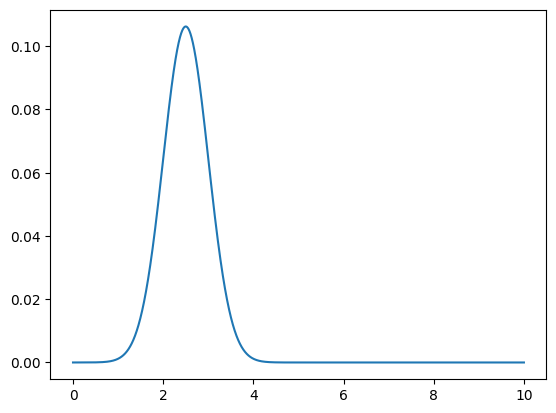

In [79]:
time_final = 10 # total time we will simulate for
N = 5000 # number of time steps

mu, sigma = 2.5, 0.5 # 2.5, 0.5 # defined for a Gaussian input pulse
T = 5 # input pulse "duration" (make sure to adjust this if input pulse changes)

# Returned area-normalized Gaussian
def gaussian(mu, sigma, t):
    return np.sqrt(1/(sigma*np.sqrt(np.pi))) * np.exp(-((t-mu)**2) / (2*sigma**2))

### INPUT COHERENT STATE
def alpha_in(t):
    amp = 0.1 # small amplitude
    return amp*(gaussian(mu, sigma, t)) 

# Same example as Gorshkov 34
'''def alpha_in(t):
    A = 2.09
    return A*(np.exp(-30*(t/(T/2)-0.5)**2)-np.exp(-7.5)) / np.sqrt(T/2)
'''
time = np.linspace(0, time_final, N)
alpha = alpha_in(time) # input signal

plt.plot(time, alpha)
print("Area of alpha:", integrate.simps(alpha**2, time))

### Optimal coupling $\beta(t)$

From Gorshkov's paper, the optimal control pulse shape to store the incoming signal $\alpha_{in}$ is given by: 

$$\beta(t)= -\frac{\gamma(1+C)-i\Delta}{\sqrt{2\gamma(1+C)}} \cdot \frac{\alpha_{in}(t)}{\sqrt{\int_0^t{|\alpha_{in}(t)|^2 dt}}} \cdot
\text{exp} \left(\frac{i \Delta \cdot h(t, T)}{\gamma^2(1+C)^2+\Delta^2} \right)$$

- $C$ is cavity cooperativity.
- $\gamma$ is decay rate of the excited state. In Gorshkov, $\gamma$ is defined as the decay rate into unwanted modes of optical polarization. $\gamma \gt \gamma_e/2$ where $\gamma_e$ is the spontaneous decay from the excited state. Here, we treat $\gamma$ as the spontaneous decay of the excited state....
- $\Delta$ is the detuning of the Raman memory
- $T$ is the duration of the input pulse
- $h(t, T) = \int_t^T |g_{se}\beta(t)|^2 dt$. $h(t, T)$ is the integrated phase accumulation due to AC stark shift. Note that this would become 0 if we rotated into an AC stark shifted frame. There will be discrete time steps in the Hamiltonian due to h(t) integrator. If we can make this more discontinuous at second order rather than first order, the simulation may scale better with time. The derivative of $h$ corresponds to the frequency and therefore energy shift.

We can rewrite this for the code as:

$$ \beta(t) = a \times b \times \text{exp} \left(\frac{i\Delta h(t, T)}{c}\right)$$
- $a = -\frac{\gamma(1+C)-i\Delta}{\sqrt{2\gamma(1+C)}}$
- $b = \frac{\alpha_{in}(t)}{\sqrt{\int_0^t{|\alpha_{in}(t)|^2dt}}}$
- $c = \gamma^2(1+C)^2+\Delta^2$

When we are computing $h(t, T)$, note that $|\beta(t)|^2$ will be $|a \cdot b|^2$. Also, we are redefining the $\Omega(t)$ in the Gorshkov paper as $\beta(t)$. 

### Accounting for AC Stark Shift
A coupling pump shifts the energy state ("dressed"), which causes a detuning on the eg transition. This makes $\alpha$ out of resonance with the eg transition. Thus, $\alpha$ may need a detuning term like $e^{i \Delta t}$ or Hamiltonian has additional delta dependence (shift excited state with an additional $\sigma_{ee}$ term). We do the latter as based on Gorshkov, we should not need to adjust $\alpha_{in}$ as our Hamiltonian includes a detuning term and $\beta$ adjusts for it.

How does AC Stark shift physically appear in qutip simulations? (do math to see the origin of AC Stark shift)

In [100]:
gamma = 1       # decay rate
C = 100           # cooperativity (higher = more efficient)
Delta = 700        # detuning

# Precompute prefactors (constants)
a = -(gamma*(1+C) - 1j*Delta) / np.sqrt(2*gamma*(1+C))
c = gamma**2*(1+C)**2 + Delta**2

# Compute b
b = [0]
for i in range(1, len(time)):
    integral_val = integrate.simps(abs(alpha[0:i])**2, time[0:i]) # integral (0 to t) of |alpha|^2
    if (integral_val == 0):
        b.append(0)
    else:      
        b.append(alpha[i] / (np.sqrt(integral_val)))
b = np.array(b)

In [101]:
# Returns the integral of |beta(t)|^2 from t[idx] to t[end_of_pulse]
def get_h(beta_vals, idx, time):
    T_index = np.where(time > T)[0][0] # find closest index corresponding to time T
    if idx >= T_index:
        h_val = 0
    else:
        h_val = integrate.simps(np.abs(beta_vals[idx:T_index])**2, time[idx:T_index]) # Integrate beta from time[idx] to time[T_index]

    return h_val

100%|██████████| 4999/4999 [00:00<00:00, 5819.89it/s]


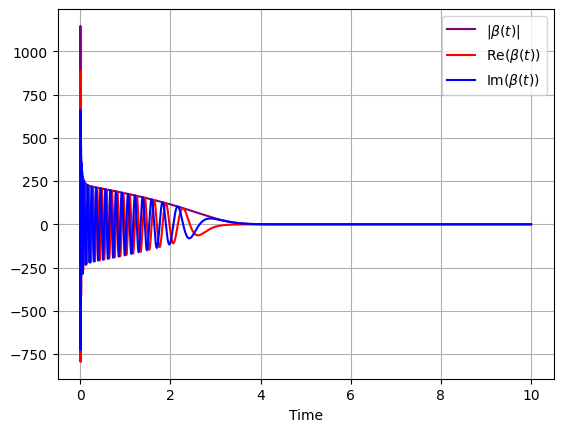

In [102]:
beta_vals = np.array([0])
h_vals = np.array([0])

for idx in tqdm(range(0, len(time)-1)):
    h = get_h(a*b, idx, time)
    if np.imag(h) != 0: print('Imaginary part detected')
    beta_vals = np.append(beta_vals, a*b[idx]*np.exp(1j*Delta*h/c))
    h_vals = np.append(h_vals, h)

def beta(t):
    if t == time[0]: return 0
    else:            return np.interp(t, time, beta_vals)  # Interpolate smoothed g values    
    
plt.plot(time, abs(beta_vals), color='purple', label=r'$|\beta(t)|$')
plt.plot(time, np.real(beta_vals), color='red', label=r'Re$(\beta(t))$')
plt.plot(time, np.imag(beta_vals), color='blue', label=r'Im$(\beta(t))$')
plt.xlabel('Time')
plt.grid()
plt.legend()

Note that we need to make sure we are sampling sufficiently in time to resolve the fast wiggles in $\beta(t)$ as seen above. 

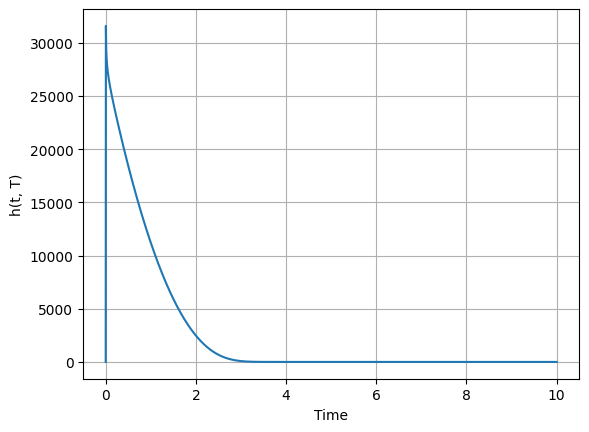

In [83]:
plt.plot(time, h_vals)
plt.xlabel('Time'); plt.ylabel('h(t, T)')
plt.grid()

## Summary thus far 

$$ \hat{H} = g_{ge} (\alpha(t)\hat{\sigma}_{ge}+ \alpha^\dagger(t)\hat{\sigma}_{eg}) +
g_{se} (\beta(t)\hat{\sigma}_{se} + \beta^\dagger(t)\hat{\sigma}_{es}) + \Delta \hat{\sigma}_{ee} $$

$$  \mathbf{L} = \begin{bmatrix} -{g_{ge}^*}\hat{\sigma}_{eg}, -\frac{1}{\sqrt{C}}{g_{ge}^*}\hat{\sigma}_{eg} \end{bmatrix} $$

We can run the following tests to see what is happening. 
1. Set $\beta(t) = 0$.  Without dissipation, we expect the signal to simply spin up the atom slightly to the excited state. Storage state should be 0. With dissipation (only eg dissipation), it should behave as the typical TLS and decay. These two cases work.

2. Set $\beta(t) = C$ (contant).

3. Set $\beta(t)$ equal to the optimal case. Without dissipation, I'm not sure what to expect because this $\beta(t)$ is tailored to the case where there is dissipation. With dissipation (eg dissipation only), the storage state probability will reach 0.01, same as the number of photons. 

### Troubleshooting with Optuna

When we were first trying to get the 3LS system working, it was unclear if we were getting factors wrong, so we added additional factors shown here and opimized with Optuna, a package that performs Bayesian optimization 

$$\beta(t)= -a_{factor} \cdot \frac{\gamma(1+C)-i\Delta}{\sqrt{2\gamma(1+C)}} \cdot \frac{\alpha_{in}(t)}{\sqrt{\int_0^t{|\alpha_{in}(t)|^2 dt}}} \cdot \text{exp} \left(\frac{i \Delta \cdot h(t, T)}{\gamma^2(1+C)^2+\Delta^2} \cdot c_{factor} \right) $$

When we ran the optimization (code in the cell below), we obtained best parameters for $a_{factor}$ and $c_{factor}$ as 0.986 and 0.908, respectively, which suggested they were both essentially 1. We did not optimize over $C$ or $\gamma$ as these are more like physical constants of a system. 

In [84]:
'''import optuna
from optuna.visualization import plot_optimization_history, plot_contour, plot_param_importances

a_factor_vals =  np.linspace(0.01, 5, 50)
c_factor_vals =  np.linspace(0.01, 5, 50)
Delta_vals = np.linspace(100, 1000, 100)
T, g_se = 10, 1
C = 100
gamma = 1

def objective_optuna(trial):
    c_factor = trial.suggest_float("c_factor", min(c_factor_vals), max(c_factor_vals))
    a_factor = trial.suggest_float("a_factor", min(a_factor_vals), max(a_factor_vals))
    Delta = trial.suggest_float("Delta", min(Delta_vals), max(Delta_vals))
    g_ge = np.sqrt(2*gamma*C)

    time, S, prob_s, prob_g, prob_e = three_level_simulation(a_factor, c_factor, C, gamma, Delta, T, g_se, g_ge, alpha_in) # MADE INTO A FUNCTION**
    return prob_s[-1]

study = optuna.create_study(direction="maximize")
study.optimize(objective_optuna, n_trials=100) # n_jobs=-1
print(study.best_params)
print(study.best_value)'''

'import optuna\nfrom optuna.visualization import plot_optimization_history, plot_contour, plot_param_importances\n\na_factor_vals =  np.linspace(0.01, 5, 50)\nc_factor_vals =  np.linspace(0.01, 5, 50)\nDelta_vals = np.linspace(100, 1000, 100)\nT, g_se = 10, 1\nC = 100\ngamma = 1\n\ndef objective_optuna(trial):\n    c_factor = trial.suggest_float("c_factor", min(c_factor_vals), max(c_factor_vals))\n    a_factor = trial.suggest_float("a_factor", min(a_factor_vals), max(a_factor_vals))\n    Delta = trial.suggest_float("Delta", min(Delta_vals), max(Delta_vals))\n    g_ge = np.sqrt(2*gamma*C)\n\n    time, S, prob_s, prob_g, prob_e = three_level_simulation(a_factor, c_factor, C, gamma, Delta, T, g_se, g_ge, alpha_in) # MADE INTO A FUNCTION**\n    return prob_s[-1]\n\nstudy = optuna.create_study(direction="maximize")\nstudy.optimize(objective_optuna, n_trials=100) # n_jobs=-1\nprint(study.best_params)\nprint(study.best_value)'

# Summary 
$$ \hat{H} = g_{ge} (\alpha(t)\hat{\sigma}_{ge}+ \alpha^\dagger(t)\hat{\sigma}_{eg}) +
g_{se} (\beta(t)\hat{\sigma}_{se} + \beta^\dagger(t)\hat{\sigma}_{es}) + \Delta \hat{\sigma}_{ee} $$

$$  \mathbf{L} = \begin{bmatrix} -{g_{ge}^*}\hat{\sigma}_{eg}, -\frac{1}{\sqrt{C}}{g_{ge}^*}\hat{\sigma}_{eg} \end{bmatrix} $$

$$\beta(t)= -a_{factor} \cdot \frac{\gamma(1+C)-i\Delta}{\sqrt{2\gamma(1+C)}} \cdot \frac{\alpha_{in}(t)}{\sqrt{\int_0^t{|\alpha_{in}(t)|^2 dt}}} \cdot \text{exp} \left(\frac{i \Delta \cdot h(t, T)}{\gamma^2(1+C)^2+\Delta^2} \cdot c_{factor} \right) = a\times b \times \text{exp} (\frac{i \Delta \cdot h(t, T)}{c})$$

-  $g_{ge} = \sqrt{2\gamma C}$ in free space (see cooperativity document). 

In [85]:
### ---------------------------- HAMILTONIAN ---------------------------------
g_se = 1
g_ge = np.sqrt(2*C*gamma) 

H_signal = sigma_ge
H_signal_dag = sigma_eg
H_coupling = sigma_se
H_coupling_dag = sigma_es
H_detuning = sigma_ee 

def H_detuning_coeff(t, args):
    return Delta

def H_signal_coeff(t, args): 
    return g_ge * alpha_in(t) 

def H_signal_dag_coeff(t, args): 
    return g_ge * np.conjugate(alpha_in(t))

def H_coupling_coeff(t, args):
    return g_se * beta(t)

def H_coupling_dag_coeff(t, args):
    return g_se * np.conjugate(beta(t))

H = [[H_detuning, H_detuning_coeff], [H_signal, H_signal_coeff], [H_signal_dag, H_signal_dag_coeff], [H_coupling, H_coupling_coeff], [H_coupling_dag, H_coupling_dag_coeff]] # Final Hamiltonian 

$$  \mathbf{L} = \begin{bmatrix} -{g_{ge}^*}\hat{\sigma}_{eg}, -{g_{se}^*} \hat{\sigma}_{es} \end{bmatrix} $$


In [86]:
# ------------------DISSIPATION OPERATORES (collapse operators)-----------------
def col_coeff_es(t, args): 
    return -np.conjugate(g_se) 

def col_coeff_eg(t, args): 
    return -np.conjugate(g_ge) 

c_op_list = [] # No dissipation
c_op_list = [[sigma_eg, col_coeff_eg], [sigma_eg, -1/np.sqrt(C)]]  # only eg dissipation
#c_op_list = [[sigma_es, col_coeff_es], [sigma_eg, col_coeff_eg], [sigma_eg, -1/np.sqrt(C)]]  # eg and es dissipation

### SIMULATE: starting from the ground state, solve Schrodinger equation
psi0 = ground # |g> 
result = mesolve(H, psi0, time, c_op_list) 

In [87]:
###--------------------- RESULTS ---------------------------
prob_g = [] # probability of finding state in |g>
prob_s = [] # probability of finding state in |s>
prob_e = [] # probability of finding state in |e>

S = [] # expectation value of |g><s|
for i in range(0, len(result.states)):
    # No dissipation (result outputs states) (comment out if using collapse operators)
    #p_g, p_s, p_e = abs(result.states[i][0])**2, abs(result.states[i][1])**2, abs(result.states[i][2])**2
    
    # With dissipation (result outputs density operators)
    p_g, p_s, p_e = result.states[i][0][0], result.states[i][1][1], result.states[i][2][2]
    
    prob_g = np.append(prob_g, p_g)
    prob_s = np.append(prob_s, p_s)
    prob_e = np.append(prob_e, p_e)

    S = np.append(S, expect(sigma_gs, result.states[i]))

Final |s> probability:  0.009933383200503795


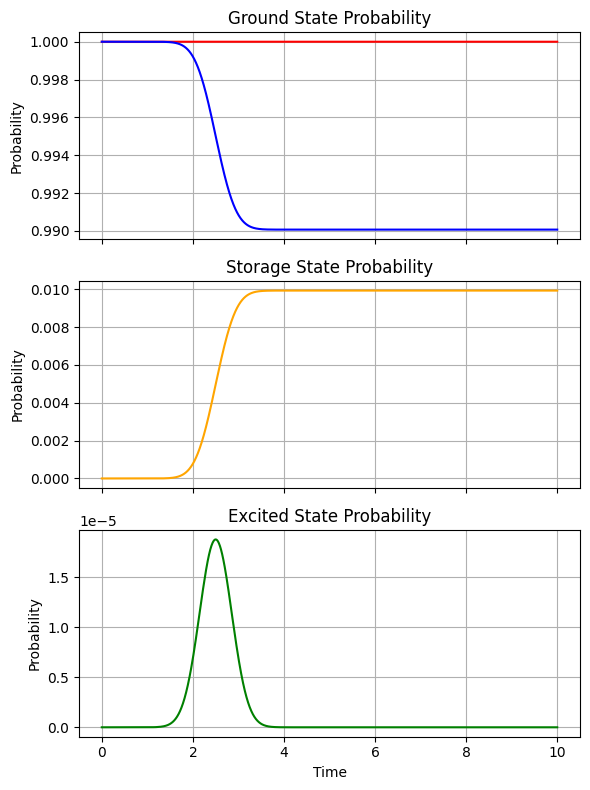

In [88]:
print('Final |s> probability: ', abs(prob_s[-1]))
fig, axs = plt.subplots(3, 1, figsize=(6, 8), sharex=True)

axs[0].plot(time, prob_g+prob_e+prob_s, color='red')
axs[0].plot(time, prob_g, color='blue')
axs[0].set_ylabel('Probability')
axs[0].set_title('Ground State Probability')
axs[0].grid()

axs[1].plot(time, prob_s, color='orange')
axs[1].set_ylabel('Probability')
axs[1].set_title('Storage State Probability')
axs[1].grid()

axs[2].plot(time, prob_e, color='green')
axs[2].set_xlabel('Time')
axs[2].set_ylabel('Probability')
axs[2].set_title('Excited State Probability')
axs[2].grid()
plt.tight_layout()

## Observations
$\beta(t)$ produces an off-resonant drive to the excited state on the other branch: manifests in small oscillations in excited state probability. (Does p_e height get adjusted depending on the storage efficiency? Or is there intrinsic probability you cannot remove in the system due to this off-resonant drive?)

### Check limits in the Gorshkov paper: 
1. $|\Delta| \gg \gamma C$ (Raman configuration)
2. Adiabatic elimination condition: $TC\gamma \gg 1$ ($T$ is the duration of the incoming pulse)
3. Maximum efficiency: $\frac{C}{1+C}$
4. $|\beta| \sim |\Delta|/ \sqrt{\gamma C T}$

In [89]:
print('1: ', Delta, gamma*C) # Delta should be much greater than gamma*C (gamma*C is decay rate for P into desired mode)
print('2: ', T*C*gamma) # Verify this is greater than 1
print('3: ', C/(1+C)) # max efficiency
print('Final |s> probability: ', abs(prob_s[-1])) # should be less than the max efficiency?

print('4: ', abs(beta_vals), Delta/np.sqrt(gamma*C*sigma)) # Should be on the same order


1:  700 300
2:  1500
3:  0.9966777408637874
Final |s> probability:  0.009933383200503795
4:  [0.00000000e+00 0.00000000e+00 0.00000000e+00 ... 5.47515379e-48
 5.15645010e-48 4.85622014e-48] 57.154760664940824


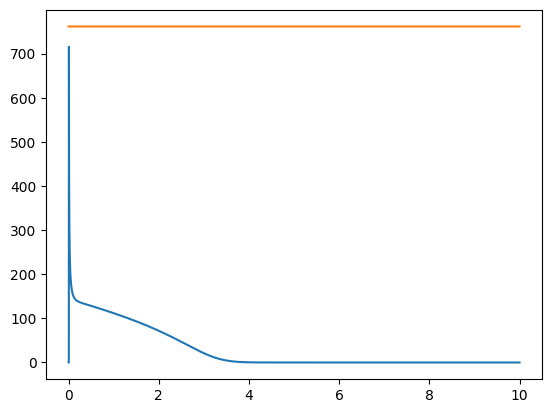

In [90]:
plt.plot(time, np.abs(beta_vals))
plt.plot(time, np.ones(len(time))*np.abs(gamma*C + 1j*Delta))